# 03 - Evaluate And Explain

Inspect GNN predictions, distributions, and top explanations.

In [10]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

if '/app' not in sys.path:
    sys.path.append('/app')

from app.ledger.db import SessionLocal
from app.core.config import settings

In [11]:
db = SessionLocal()
try:
    q = text('''
        SELECT entity_key, entity_type, score, reason_codes, window_end
        FROM ai_prediction
        WHERE prediction_type = :ptype
        ORDER BY window_end DESC, score DESC
        LIMIT 200
    ''')
    rows = db.execute(q, {'ptype': settings.gnn_prediction_type}).fetchall()
finally:
    db.close()

df = pd.DataFrame(rows, columns=['entity_key', 'entity_type', 'score', 'reason_codes', 'window_end'])
df.head(20)

,entity_key,entity_type,score,reason_codes,window_end
0,ip:203.0.113.1,ip,98.3990,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
1,ip:203.0.113.2,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
2,ip:203.0.113.3,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
3,ip:203.0.113.4,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
4,ip:203.0.113.7,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
5,ip:203.0.113.10,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
6,ip:203.0.113.5,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
7,ip:203.0.113.9,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
8,ip:203.0.113.8,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00
9,ip:203.0.113.6,ip,98.3989,"[CAMPAIGN_LINKED, EVENT_VOLUME_MED, GNN_RISK_C...",2026-01-02 14:33:20.916951+00:00


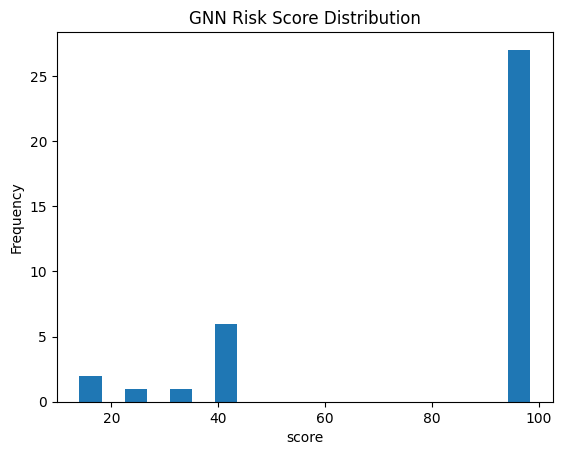

In [12]:
if not df.empty:
    ax = df['score'].astype(float).plot(kind='hist', bins=20, title='GNN Risk Score Distribution')
    ax.set_xlabel('score')
    plt.show()
else:
    print('No GNN predictions found yet.')

In [13]:
db = SessionLocal()
try:
    q = text('''
        SELECT p.entity_key, p.score, e.reason_codes, e.evidence_hashes
        FROM ai_prediction p
        JOIN ai_explanation e ON e.prediction_id = p.id
        WHERE p.prediction_type = :ptype
        ORDER BY p.window_end DESC, p.score DESC
        LIMIT 10
    ''')
    top = db.execute(q, {'ptype': settings.gnn_prediction_type}).fetchall()
    for row in top:
        print('entity=', row[0], 'score=', row[1])
        print('reasons=', row[2])
        print('evidence_count=', len(row[3] or []))
        print('---')
finally:
    db.close()

entity= ip:203.0.113.1 score= 98.399
reasons= ['CAMPAIGN_LINKED', 'EVENT_VOLUME_MED', 'GNN_RISK_CRITICAL', 'TOP_EVENT_DDOS_SIGNAL_EVENT', 'VPN_INFRA_REUSE']
evidence_count= 8
---
entity= ip:203.0.113.8 score= 98.3989
reasons= ['CAMPAIGN_LINKED', 'EVENT_VOLUME_MED', 'GNN_RISK_CRITICAL', 'TOP_EVENT_DDOS_SIGNAL_EVENT', 'VPN_INFRA_REUSE']
evidence_count= 8
---
entity= ip:203.0.113.2 score= 98.3989
reasons= ['CAMPAIGN_LINKED', 'EVENT_VOLUME_MED', 'GNN_RISK_CRITICAL', 'TOP_EVENT_DDOS_SIGNAL_EVENT', 'VPN_INFRA_REUSE']
evidence_count= 8
---
entity= ip:203.0.113.3 score= 98.3989
reasons= ['CAMPAIGN_LINKED', 'EVENT_VOLUME_MED', 'GNN_RISK_CRITICAL', 'TOP_EVENT_DDOS_SIGNAL_EVENT', 'VPN_INFRA_REUSE']
evidence_count= 8
---
entity= ip:203.0.113.5 score= 98.3989
reasons= ['CAMPAIGN_LINKED', 'EVENT_VOLUME_MED', 'GNN_RISK_CRITICAL', 'TOP_EVENT_DDOS_SIGNAL_EVENT', 'VPN_INFRA_REUSE']
evidence_count= 8
---
entity= ip:203.0.113.4 score= 98.3989
reasons= ['CAMPAIGN_LINKED', 'EVENT_VOLUME_MED', 'GNN_RISK_CRIT